# SCS 3546: Deep Learning
> **Assignment 4: Generative Models**

## **Assignment Description**
***
In this assignment, you are generating sample images of shapes3DLinks to an external site. with deep convolutional Variational Autoencoder

You need to do the following:

1. Download data

2. Rescale data by 1./255. You can find documentation on scaling hereLinks to an external site.

3. Build a Convolutional Variational Autoencoder with four layers and a coding size of 2. You can find a sample architecture hereLinks to an external site.

4. Train your model with gradient tape and feed input and output the same data

5. Show the 2D manifolds of the codes. You can find an example hereLinks to an external site.



# Setup, Data Import and Preprocessing



In [ ]:
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow_probability as tfp
from tensorflow.keras import layers

In [ ]:
# Use 30% of data
train_dataset, info = tfds.load('shapes3d', split='train[:30%]', with_info=True)


In [ ]:
# Preprocessing function: converts image pixels from uint8 to float32 and rescales to [0.0, 1.0]
def preprocess(example):
    image = tf.cast(example['image'], tf.float32) / 255.0
    return image

train_dataset = (
    train_dataset
    # Apply preprocessing to each image (rescaling)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # Shuffle dataset with buffer size 1024 and fixed seed for reproducibility
    .shuffle(buffer_size=1024, seed=42)

    # Batch the dataset into groups of 64 examples
    .batch(64)

    # Prefetch batches to optimize pipeline performance
    .prefetch(tf.data.AUTOTUNE)
)

#Build a Convolutional Variational Autoencoder with four layers and a coding size of 2

## Build Encoder

In [ ]:
def build_encoder(latent_dim):
    """Constructs the encoder network."""
    return keras.Sequential([
        layers.InputLayer(input_shape=(64, 64, 3), name="encoder_input"),
        layers.Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(latent_dim * 2, name="z_mean_logvar"),  # Outputs both mean and log variance
    ], name="Encoder")

## Build Decoder

In [ ]:
def build_decoder(latent_dim):
    """Constructs the decoder network."""
    return keras.Sequential([
        layers.InputLayer(input_shape=(latent_dim,), name="decoder_input"),
        layers.Dense(units=16 * 16 * 32, activation='relu'),
        layers.Reshape(target_shape=(16, 16, 32)),
        layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(3, kernel_size=3, strides=1, padding='same', name="decoder_output")
    ], name="Decoder")

## Create Convolutional VAE

In [ ]:
class ConvolutionalVAE(keras.Model):
    def __init__(self, latent_dim=2, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.encoder = build_encoder(latent_dim)
        self.decoder = build_decoder(latent_dim)

    def encode(self, x):
        """Returns the mean and log variance of the latent distribution."""
        z = self.encoder(x)
        z_mean, z_log_var = tf.split(z, num_or_size_splits=2, axis=1)
        return z_mean, z_log_var

    def reparameterize(self, z_mean, z_log_var):
        """Applies the reparameterization trick."""
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def decode(self, z, apply_sigmoid=False):
        """Decodes latent vector back into image."""
        x_logit = self.decoder(z)
        return tf.sigmoid(x_logit) if apply_sigmoid else x_logit

    @tf.function
    def sample(self, eps=None):
        """Generates samples from prior."""
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

# Wrap CVAE inside a new VAE class

In [ ]:
class VAETrainer(keras.Model):
    def __init__(self, vae_model, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.vae_model = vae_model
        self.beta = beta  # Constant KL weight (β)
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.kl_weight_tracker = keras.metrics.Mean(name="kl_weight")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
            self.kl_weight_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.vae_model.encode(data)
            z = self.vae_model.reparameterize(z_mean, z_log_var)
            reconstruction = self.vae_model.decode(z, apply_sigmoid=True)

            # Reconstruction loss (binary cross-entropy)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            # Total loss with constant β
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.vae_model.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.vae_model.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.kl_weight_tracker.update_state(self.beta)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "kl_weight": self.kl_weight_tracker.result()
        }


## Train Model (β = 1.0) – Baseline



In [ ]:
# Create model
vae_model_beta_1 = ConvolutionalVAE(latent_dim=2)
vae_trainer_beta_1 = VAETrainer(vae_model_beta_1, beta=1.0)

# Compile
vae_trainer_beta_1.compile(optimizer=keras.optimizers.Adam())

# Train
history_beta_1 = vae_trainer_beta_1.fit(
    train_dataset,
    epochs=30,
    verbose=1
)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2250/2250 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - kl_loss: 8.9158 - kl_weight: 1.0000 - loss: 1990.4038 - reconstruction_loss: 1981.4873
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.9888 - kl_weight: 1.0000 - loss: 1550.2748 - reconstruction_loss: 1540.2858
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.5509 - kl_weight: 1.0000 - loss: 1533.9971 - reconstruction_loss: 1524.4465
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.3101 - kl_weight: 1.0000 - loss: 1524.3732 - reconstruction_loss: 1515.0623
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.1864 - kl_weight: 1.0000 - loss: 1520.5756 - reconstruction_loss: 1511.3888
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.1319 - kl_weight: 1.0000 - loss: 1515.4984 - reconstruction_loss: 1506.3660
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 9.1271 - kl_weight: 1.0000 - loss: 1512.7289 - reconstruction_loss: 1503.6029
Epo

### Plot Loss Curves

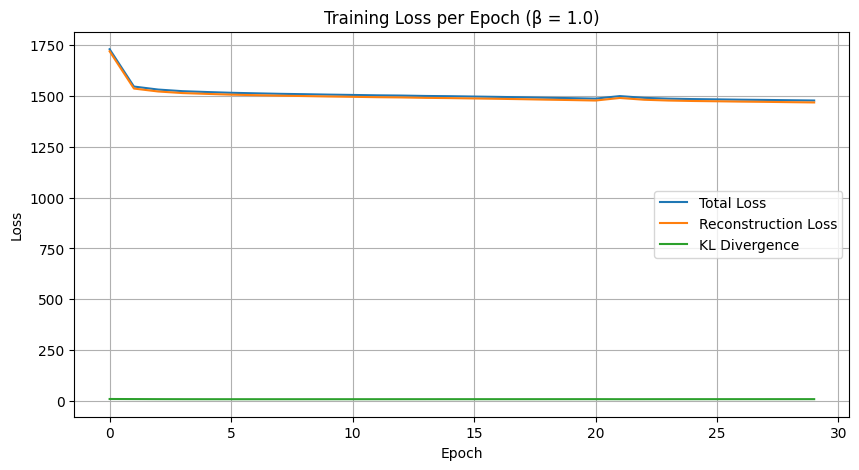

In [ ]:
def plot_loss_curves(history, beta_label=""):
    """Plot training loss curves from model.fit()."""
    plt.figure(figsize=(10, 5))

    # Total loss
    plt.plot(history.history["loss"], label="Total Loss")

    # Individual components
    if "reconstruction_loss" in history.history:
        plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
    if "kl_loss" in history.history:
        plt.plot(history.history["kl_loss"], label="KL Divergence")

    plt.title(f"Training Loss per Epoch (β = {beta_label})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_loss_curves(history_beta_1, beta_label="1.0")


In [ ]:
# ### 📉 Training Loss Curve Analysis

# - **Total vs. Reconstruction Loss**
#   The total loss almost entirely overlaps with the reconstruction loss, indicating that the **KL divergence contributes very little** to the overall objective.

# - **KL Divergence Near-Zero**
#   The KL loss remains close to zero across all epochs. This is a clear sign of **posterior collapse**, meaning the model is not effectively using the latent space — a common issue in VAEs with small latent dimensions or overly strong decoders.

# - **Stable but Flat Training**
#   Losses remain stable throughout the 30 epochs with minimal fluctuations, suggesting **numerical stability** but also **limited learning progress** after early epochs.

# - **Under-regularization**
#   With such low KL contribution, the model may behave like a deterministic autoencoder. This leads to **poor generalization** and low-quality sampling from latent space.


### Visualize Reconstructions (β = 1.0)

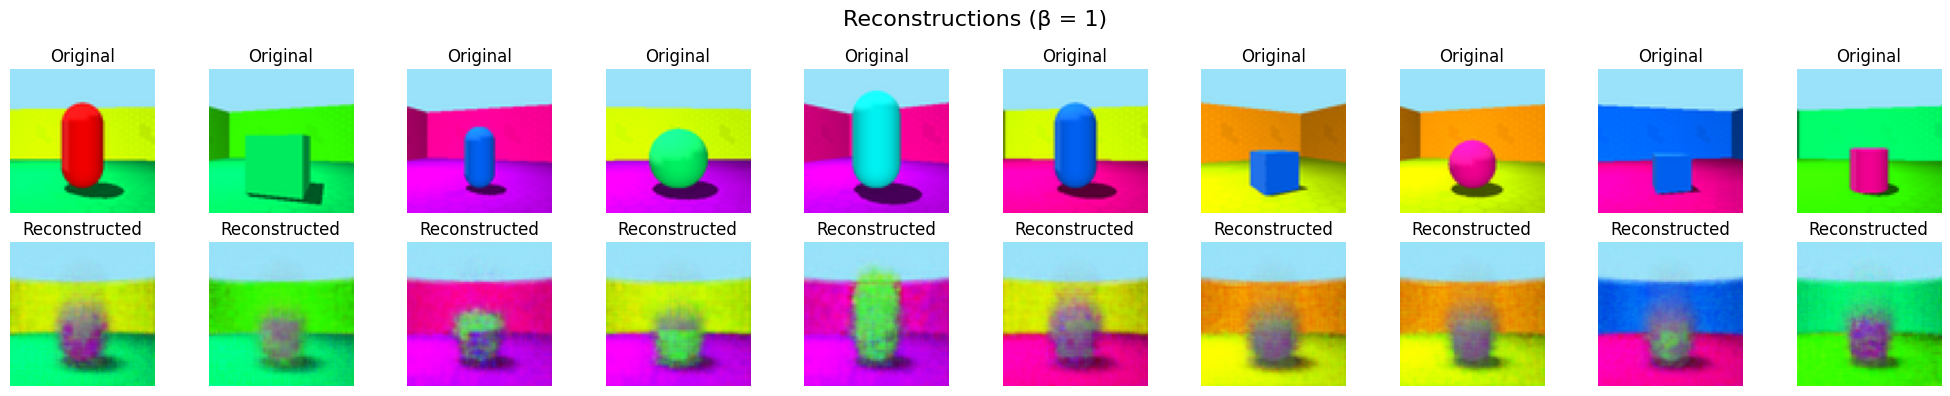

In [ ]:
def display_reconstructions(model, dataset, num_images=10, beta_label=""):
    """Display original and reconstructed images side by side."""
    import matplotlib.pyplot as plt

    # Get a batch of images
    for batch in dataset.take(1):
        original = batch[:num_images]
        break

    z_mean, z_log_var = model.encode(original)
    z = model.reparameterize(z_mean, z_log_var)
    reconstructed = model.decode(z, apply_sigmoid=True)

    # Plot side-by-side
    plt.figure(figsize=(num_images * 2, 4))
    plt.suptitle(f"Reconstructions (β = {beta_label})", fontsize=16)

    for i in range(num_images):
        # Original
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Call the function
display_reconstructions(vae_model_beta_1, train_dataset, beta_label="1")


In [ ]:
# ### 🧠 Reconstruction Quality Summary

# - **Blurry and Washed-Out**: Reconstructions lack sharpness and texture; fine details are lost.
# - **Low Color Fidelity**: Basic color/layout is preserved, but saturation is weak — signs of underfitting.
# - **Poor Shape Recovery**: Object shapes are unrecognizable, suggesting a limited latent representation.
# - **Possible Posterior Collapse**: Very low KL divergence implies the latent space isn't being used.
# - **Capacity or Training Issue**: Could be due to short training or overly small latent dimension (`latent_dim=2`).


### Show the 2D manifolds of the codes (β = 1.0)

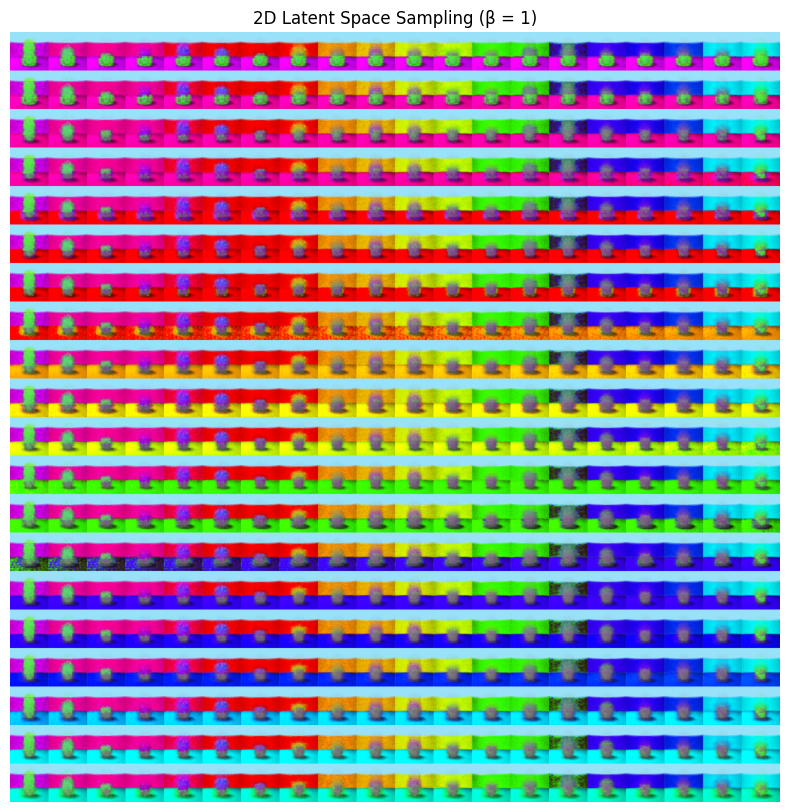

In [ ]:
def plot_latent_images(model, n=20, image_size=64, beta_label=""):
    """Plots an n x n grid of images decoded from 2D latent space."""
    norm = tfp.distributions.Normal(0, 1)
    grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
    grid_y = norm.quantile(np.linspace(0.05, 0.95, n))

    image_height = image_size * n
    image_width = image_size * n
    canvas = np.zeros((image_height, image_width, 3))  # RGB

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z = np.array([[xi, yi]], dtype=np.float32)
            x_decoded = model.decode(z, apply_sigmoid=True)
            img = tf.reshape(x_decoded[0], (image_size, image_size, 3)).numpy()

            top = i * image_size
            left = j * image_size
            canvas[top:top + image_size, left:left + image_size, :] = img

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas)
    plt.axis("off")
    plt.title(f"2D Latent Space Sampling (β = {beta_label})")
    plt.show()


plot_latent_images(vae_model_beta_1, n=20, beta_label="1")


In [ ]:
# 2D Latent Space Sampling – β = 1.0 (Baseline Model)

# Latent space shows smooth and structured transitions**, indicating that the model successfully learned a continuous 2D representation of the data.
# Color gradients vary gradually across axes**, suggesting that latent dimensions capture meaningful visual features like background hue and object color.
# Consistent object presence** across samples demonstrates the decoder utilizes latent codes to generate diverse yet coherent outputs.
# Visual quality remains low/fuzzy**, indicating that while the latent structure is well-formed, the decoder's reconstruction fidelity could be improved.


# Train VAE with Moderate KL Weight (β = 0.5)

In [ ]:
# Create model
vae_model_beta_05 = ConvolutionalVAE(latent_dim=2)
vae_trainer_beta_05 = VAETrainer(vae_model_beta_05, beta=0.5)

# Compile
vae_trainer_beta_05.compile(optimizer=keras.optimizers.Adam())

# Train
history_beta_05 = vae_trainer_beta_05.fit(
    train_dataset,
    epochs=30,
    verbose=1
)


Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - kl_loss: 10.4048 - kl_weight: 0.5000 - loss: 1969.4777 - reconstruction_loss: 1964.2748
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 11.2748 - kl_weight: 0.5000 - loss: 1537.1948 - reconstruction_loss: 1531.5574
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 10.6262 - kl_weight: 0.5000 - loss: 1528.6133 - reconstruction_loss: 1523.3009
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 10.3578 - kl_weight: 0.5000 - loss: 1523.0497 - reconstruction_loss: 1517.8708
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 10.2383 - kl_weight: 0.5000 - loss: 1518.7554 - reconstruction_loss: 1513.6354
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 10.1595 - kl_weight: 0.5000 - loss: 1514.4066 - reconstruction_loss: 1509.3270
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 10.1972 - kl_weight: 0.5000 - loss: 1510.1547 - reconstruction_l

## Plot Loss Curves with KL Weight (β = 0.5)

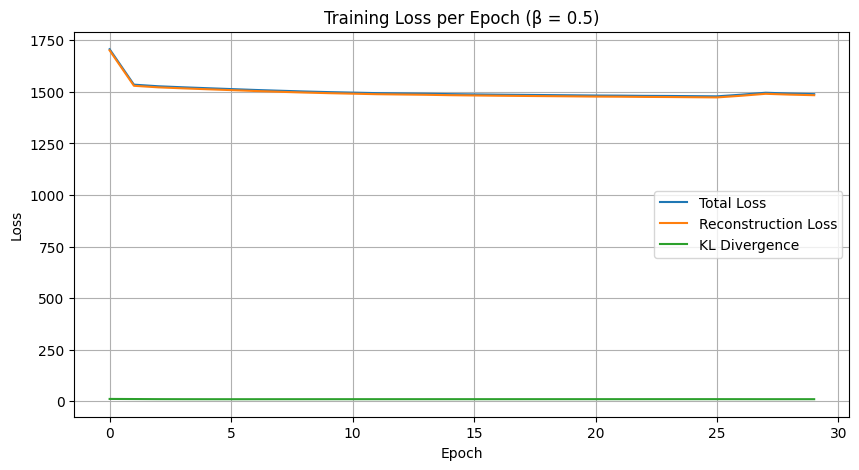

In [ ]:
plot_loss_curves(history_beta_05, beta_label="0.5")

## Visualize Reconstructions (β = 0.5)

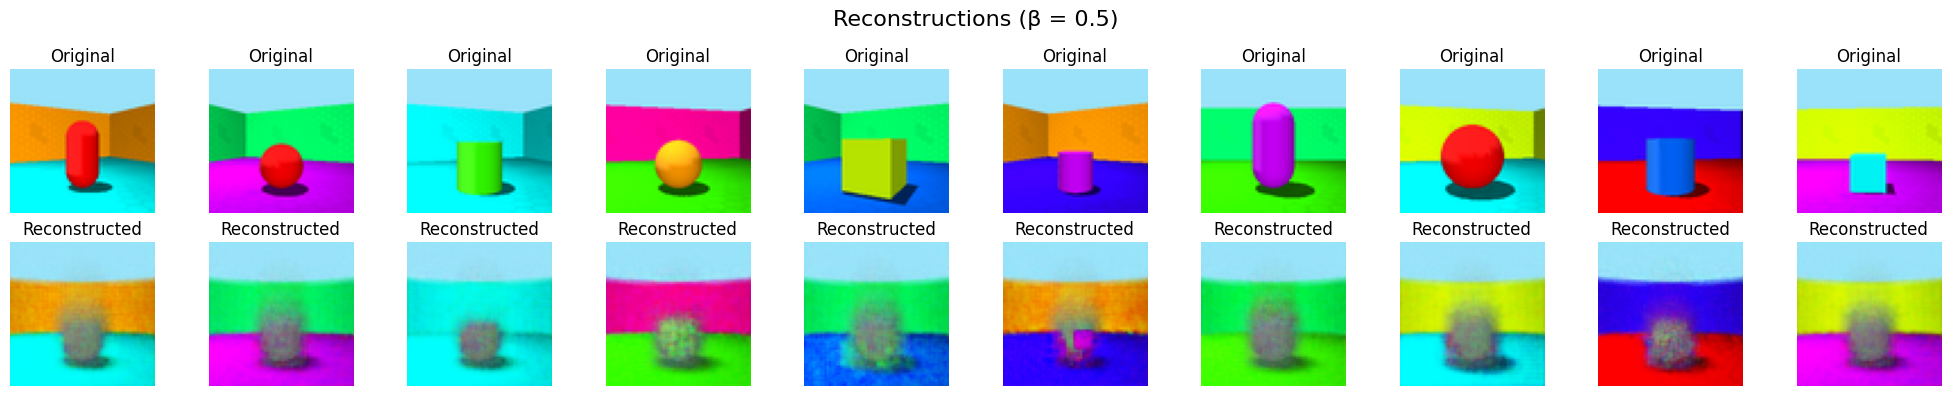

In [ ]:
display_reconstructions(vae_model_beta_05, train_dataset, beta_label="0.5")


In [ ]:
## Reconstructions (β = 0.5)

# Object shapes are roughly preserved**, but fine details like contours and edges are lost in the reconstructions.
# Background colors and spatial layouts are somewhat retained**, though reconstructions appear heavily blurred and noisy.
# Latent space may be under-regularized**, leading to reconstructions dominated by reconstruction loss and poor disentanglement.


## Show the 2D manifolds of the codes (β = 0.5)

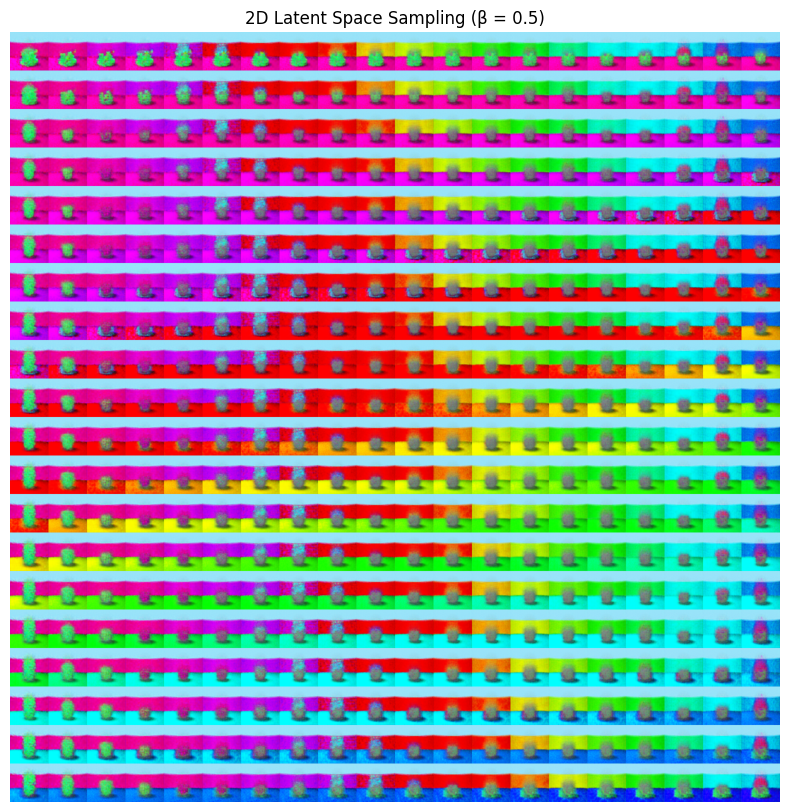

In [ ]:
plot_latent_images(vae_model_beta_05, n=20, beta_label="0.5")

In [ ]:
## 2D Latent Space Sampling (β = 0.5)

# Smooth transitions across the grid indicate some degree of latent space continuity and structure.
# Object identity remains mostly stable, but transitions between different object types or poses are less distinct.
# Some blurriness and color bleeding persist, suggesting limited disentanglement and suboptimal use of latent dimensions.


# Train VAE with Weak KL Weight (β = 0.1)

In [ ]:
# Create model
vae_model_beta_01 = ConvolutionalVAE(latent_dim=2)
vae_trainer_beta_01 = VAETrainer(vae_model_beta_01, beta=0.1)

# Compile
vae_trainer_beta_01.compile(optimizer=keras.optimizers.Adam())

# Train
history_beta_01 = vae_trainer_beta_01.fit(
    train_dataset,
    epochs=30,
    verbose=1
)


Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - kl_loss: 31.4958 - kl_weight: 0.1000 - loss: 2026.1128 - reconstruction_loss: 2022.9636
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 25.2821 - kl_weight: 0.1000 - loss: 1553.0380 - reconstruction_loss: 1550.5104
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 20.9861 - kl_weight: 0.1000 - loss: 1537.4205 - reconstruction_loss: 1535.3214
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 19.0067 - kl_weight: 0.1000 - loss: 1530.0885 - reconstruction_loss: 1528.1887
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 17.9589 - kl_weight: 0.1000 - loss: 1523.9377 - reconstruction_loss: 1522.1427
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 17.3533 - kl_weight: 0.1000 - loss: 1519.5769 - reconstruction_loss: 1517.8417
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - kl_loss: 16.8524 - kl_weight: 0.1000 - loss: 1515.9462 - reconstruction_l

## Plot Loss Curves with KL Weight (β = 0.1)

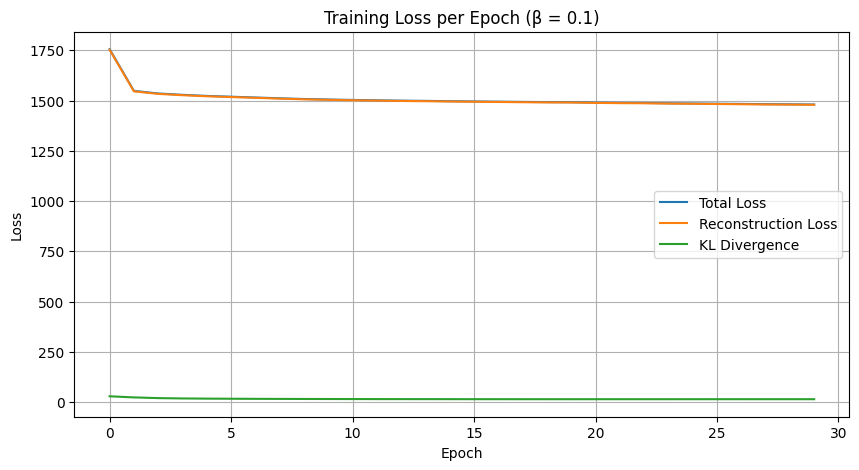

In [ ]:
plot_loss_curves(history_beta_01, beta_label="0.1")

In [ ]:
## Training Loss per Epoch (β = 0.1)

# Divergence remains low throughout training, indicating weak regularization of the latent space.
# Reconstruction loss dominates, meaning the model prioritizes pixel-level accuracy over latent space structure.
# Total loss closely follows reconstruction loss, confirming that KL contribution is minimal due to small β.


## Visualize Reconstructions (β = 0.1)

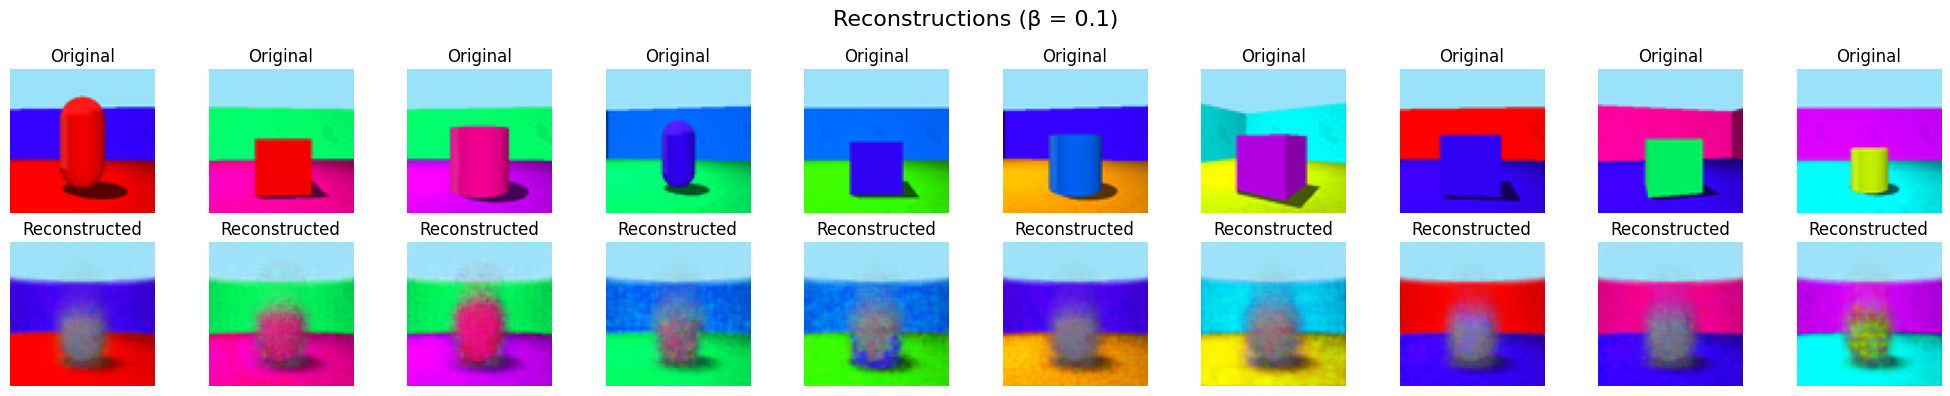

In [ ]:
display_reconstructions(vae_model_beta_01, train_dataset, beta_label="0.1")

## Show the 2D manifolds of the codes (β = 0.1)

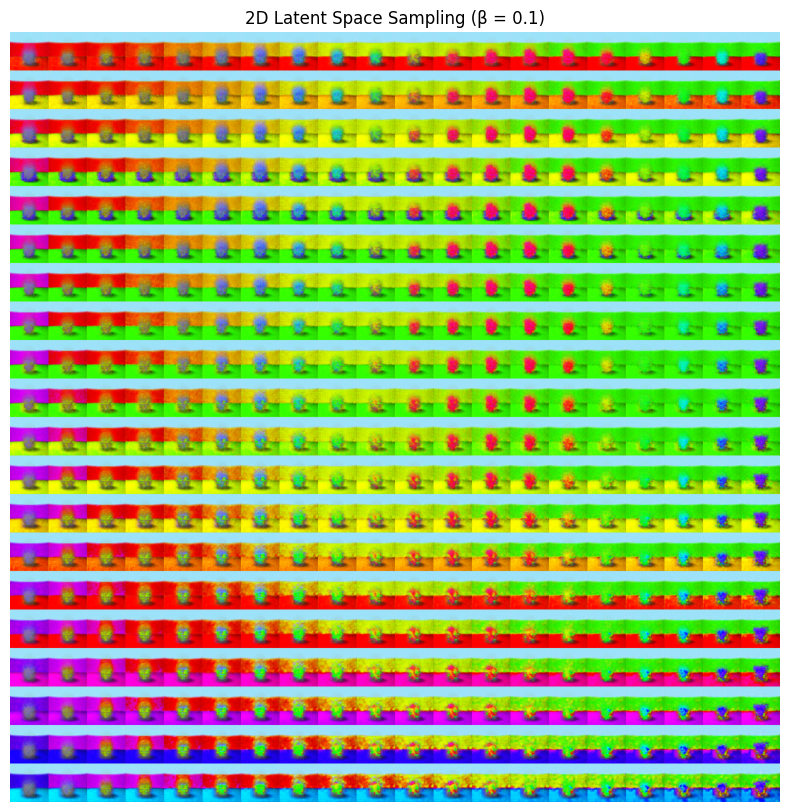

In [ ]:
plot_latent_images(vae_model_beta_01, n=20, beta_label="0.1")

In [ ]:
# 2D Latent Space Sampling (β = 0.1)

# Samples are locally smooth, but transitions across the grid lack clear structure or disentanglement.
# Image content appears blurry and redundant, suggesting poor utilization of the latent space.
# Low KL regularization (β = 0.1) leads to overfitting on reconstruction while sacrificing latent space organization.


In [ ]:
### Overall Conclusion for Models with β = 1.0, 0.5, and 0.1

# KL Weight (β) balances reconstruction vs. regularization: Lower β (e.g., 0.1) prioritizes reconstruction at the expense of structured latent space; higher β (e.g., 1.0) enforces more regularization but sacrifices reconstruction quality.

# Latent space quality improves with higher β: The model with β = 1.0 exhibits better-organized and interpretable 2D latent manifolds, while β = 0.1 results in noisy, entangled latent representations.

# Reconstruction quality declines with increasing β: β = 0.1 achieves the sharpest reconstructions, whereas β = 1.0 produces blurrier outputs, reflecting the trade-off inherent in VAEs.

# Training loss curves show minimal variation: Despite different β values, overall loss and reconstruction loss follow similar patterns across epochs, indicating stable training under all settings.

# β-VAE tuning is task-dependent: If reconstruction fidelity is the priority, a smaller β (e.g., 0.1–0.5) is beneficial; for disentangled, generative representations, higher β (e.g., 1.0) is more effective.
